### Scenario 2: Modified Montúfar Example 1 (More linear regions in some dimensions than others)

In this example, we compare the different sampling methods in a setup where we have many cuts in a 2D plane but no cuts in the other dimensions, so the linear regions form a grid in that 2D plane and are extruded into the higher dimensions. 

We find that when the regions are shaped like this, low-discrepancy sequences perform best and a grid performs the worst, because low-discrepancy sequences have the best 2D projections which is what matters in this setting.

#### Imports:

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import scipy.stats.qmc as qmc
from pathlib import Path
from itertools import groupby

#### Figure Settings

In [108]:
plt.rcParams.update(
    {
        "axes.labelsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
    }
)

#### Functions to generate/load point sets:

In [66]:
def iid_uniform_sample(num_points,dimensions,runs,lower_bounds, upper_bounds, rng):
    """Generates several iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: a pseudo-random number generator used to generate the point set
    Returns:
        points: 3D array of shape (runs,num_points,dimensions) representing all the points across all the samples
    """
    
    # Generate points in [0,1)^d
    points = rng.uniform(size=(runs,num_points,dimensions))
    
    # Map points to desired rectangular region
    points = lower_bounds + (upper_bounds - lower_bounds)*points

    # Map to torch tensor
    points = torch.tensor(points)
    
    return points

In [67]:
def halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng):
    """Generates several halton samples of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: a pseudo-random number generator used to generate the point sets
    Returns:
        points: 3D array of shape (runs, num_points, dimensions)
    """

    points = np.empty((runs,num_points,dimensions))
    
    for i in range(runs):
        sampler = qmc.Halton(d=dimensions,scramble=True,seed=rng)
        points[i,:,:] = sampler.random(num_points)

    points = points*(upper_bounds - lower_bounds) + lower_bounds

    # Convert to torch tensor for neural network processing
    points = torch.tensor(points)
    
    return points

In [68]:
def sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,rng):
    """Generates several sobol samples of points with different sample sizes
    Args:
        sample_sizes: a list of sample sizes to use for the region counting
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: a pseudo-random number generator used to generate the point sets
    Returns:
        all_points: a list of 3D arrays of shape (runs, num_points, dimensions)
    """

    all_points = []

    for i in range(len(sample_sizes)):
        
        points = np.empty((runs,sample_sizes[i],dimensions))
        
        for j in range(runs):
            
            sampler = qmc.Sobol(d=dimensions,scramble=True,seed=rng)
            points[j,:,:] = sampler.random(sample_sizes[i])

        points = points*(upper_bounds - lower_bounds) + lower_bounds

        # Convert to torch tensor so we can put through the neural network
        points = torch.tensor(points)
        
        all_points.append(points)

    return all_points

In [69]:
def load_blue_noise_points(path, lower_bound, upper_bound):
    """Formats the blue noise point sets in a way that they can be used for the experiments
    Args:
        path: location where the blue noise point sets are stored
        lower_bounds: lower bound for all dimensions to adjust blue noise point sets from [0,1]^d
        upper_bounds: upper bound for all dimensions to adjust blue noise point sets from [0,1]^d
    Returns:
        blue_noise_sets: a list of lists containing the blue noise points for each dimension
                         and sample size within that dimension
    """

    dir_path = Path(path)

    def get_metadata(path_obj):
        parts = path_obj.stem.split('_')
        return int(parts[3]),int(parts[2])

    sorted_file_paths = sorted(dir_path.glob('*.npy'),key=get_metadata)

    blue_noise_sets = []

    for dimension, group in groupby(sorted_file_paths, key = lambda p: get_metadata(p)[0]):
        lower_bounds = np.full(dimension,lower_bound)
        upper_bounds = np.full(dimension,upper_bound)
        sublist_data = []
        for file_path in group:
            point_set = lower_bounds + np.load(str(file_path),mmap_mode="r")*(upper_bounds-lower_bounds)
            point_set = torch.tensor(point_set)
            sublist_data.append(point_set)
        blue_noise_sets.append(sublist_data)

    return blue_noise_sets

In [70]:
def grid_sample(sample_sizes, dimensions, lower_bound, upper_bound):
    """Generates a sample of n=m^d points in a regular lattice
    Args:
        sample sizes: a list of values of m (the number of points on each axis to construct the grid)
        dimensions: d (the number of dimensions of the input space)
        lower_bound: the lower bound of the input space in each dimension
        upper_bound: the upper bound of the input space in each dimension
    Returns:
        grid_sample: the grid of points
    """

    samples = []

    for points_per_axis in sample_sizes:

        # Exclude the endpoint along each axis because we are looking at the number of regions in [0,1)^d with 1 excluded
        coordinate_arrays = [np.linspace(lower_bound,upper_bound,int(points_per_axis)) for i in range(dimensions)]
        meshes = np.meshgrid(*coordinate_arrays,indexing="ij")
        grid_sample = np.column_stack([m.ravel() for m in meshes])
        grid_sample = torch.tensor(grid_sample)
        grid_sample = torch.unsqueeze(grid_sample,dim=0)

        samples.append(grid_sample)

    return samples

#### Code to set up MLP

In [71]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None,custom_biases=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
            custom_biases: None if Kaiming normal initialisation is to be used, otherwise a list of 1D torch tensors,
                            representing the bias of each neuron in each layer of the neural network
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=True)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=True)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[int(i/2)])
                        self.layers[i].bias.copy_(custom_biases[int(i/2)])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution and biases according to a uniform distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)
            torch.nn.init.uniform_(module.bias,a=-1.0,b=1,generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 3D array of inputs of shape (number of runs, number of points, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 3D array of shape: (number of runs, number of points, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after ReLU layers (>0 if on, =0 if off)
            if isinstance(layer,torch.nn.ReLU):
                # If we do not have the first layer, concatenate the activations along the last axis
                try:
                    activations = torch.cat((activations,x),axis=-1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x
        return activations

#### Code to count linear regions

Online region counting function which uses subsets of a larger sample (for Binomial Point Process/Halton Sequence):

In [72]:
def region_count_online(input_points,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        points: torch tensor of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    unique_counts = torch.zeros((input_points.shape[0],input_points.shape[1]))

    # Get array of activations with shape (number of runs, number of points, total number of neurons)
    activations = model(input_points)
    # For all the activations that are greater than 0, set the state to 1
    states = torch.zeros(activations.shape)
    states[activations>0] = 1
    states = states.to(torch.int64)
    
    # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
    cols = states.shape[-1]
    powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
    activation_patterns = (states * powers).sum(dim=-1)

    # COUNT NUMBER OF UNIQUE REGIONS

    # Sort the activation patterns and get corresponding indices (stable = True ensures the first occurance is put first)
    sorted_t, indices = torch.sort(activation_patterns, dim=1, stable=True)
    
    # Find the first occurance of each new activation pattern as a Boolean Mask
    is_first_sorted = torch.ones_like(activation_patterns, dtype=torch.bool)
    is_first_sorted[:, 1:] = sorted_t[:, 1:] != sorted_t[:, :-1]
    
    # Put the true and false values back in their original order
    is_first_chronological = torch.empty_like(is_first_sorted)
    is_first_chronological.scatter_(dim=1, index=indices, src=is_first_sorted)
    
    # Count the number of true values up to each column using cumulative sum function in torch
    unique_counts = is_first_chronological.int().cumsum(dim=1)

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        first_patterns = activation_patterns[0,:]
        unique_patterns = first_patterns[is_first_chronological[0,:]]
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_first = input_points[0,:,:]
            samples_by_region[pattern] = input_points_first[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

Offline region counting function which uses separate sample sizes (for Sobol Sequence/Gaussian Blue Noise)

In [73]:
def region_count_offline(input_points_list,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        input_points_list: list of torch tensors of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    runs = input_points_list[0].shape[0]
    unique_counts = torch.zeros((runs,len(input_points_list)))

    for i in range(len(input_points_list)):

        input_points = input_points_list[i]

        # Get array of activations with shape (number of runs, number of points, total number of neurons)
        activations = model(input_points)
        # For all the activations that are greater than 0, set the state to 1
        states = torch.zeros(activations.shape)
        states[activations>0] = 1
        states = states.to(torch.int64)
        
        # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
        cols = states.shape[-1]
        powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
        activation_patterns = (states * powers).sum(dim=-1)
    
        # COUNT NUMBER OF UNIQUE REGIONS
    
        sorted_t, _ = torch.sort(activation_patterns, dim=1)
        changes = sorted_t[:, 1:] != sorted_t[:, :-1]
        counts_sample_size = changes.sum(dim=1) + 1

        unique_counts[:,i] = counts_sample_size

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        unique_patterns = torch.unique(activation_patterns[0,:])
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_final_samples = input_points_list[-1][0,:,:]
            samples_by_region[pattern] = input_points_final_samples[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

#### Experiment Function

We can modify the Montúfar example so that we have many more divisions in one axis than another (eg we might have 100 divisions in dimension 0, 1 division in dimension 1 and 1 division in dimension 2). Since we need the same number of points in each axis in the grid, the number of grid points required will grow exponentially, even though most points are wasted. Low discrepancy sequences have better low-dimensional projections than a grid, so we should get faster convergence out of using them.

Setup:
- Single hidden layer with 24 + $d-2$ neurons
- 24 neurons creates 2D lattice
- $d-2$ extra neurons fill in the remaining dimensions with no cuts

In [74]:
def scenario_2(sample_points,p,dimensions,runs=100,mode="online",return_samples=False):
    """Experiment for region counting using modified Montufar hypercubes example
    Args:
        sample_points: the sampling points used to count the regions - either numpy array (online counting) or list of arrays (offline)
        p: the number of divisions in each of the "dense" dimensions
        dimensions: the number of input dimensions
        runs: the number of times to rerun the experiment with different independent samples
        mode: whether to use the online/offline version of the region counting function
              online is used for BPP/Halton and offline for Sobol/Blue Noise
    Returns:
        unique_counts: 2D array of number of regions found after each number of samples for the different runs
    """

    custom_weights = []
    
    # Set weights in "dense" dimension
    for i in range(2):
        segment_weights = [0 for j in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights for _ in range(p)]
    
    # Set weights in sparse dimensions (remember 0 indexing => dimension 2 at index 1)
    for i in range(2,dimensions):
        segment_weights = [0 for i in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights]

    custom_weights = [torch.tensor(custom_weights)]

    custom_biases = []

    # Set biases in "dense" dimension
    for i in range(2):
        segment_biases = [-i/p for i in range(p)]
        custom_biases += segment_biases

    # Set biases in sparse dimensions
    for i in range(2,dimensions):
        custom_biases.append(0)

    custom_biases = [torch.tensor(custom_biases)]

    # Set up neural network - number of hidden neurons is p*n0 rather than hidden_neurons because the remainder neurons have weights
    # and biases set to 0 so they are essentially "dummy" neurons
    neurons_per_hidden = [2*p+dimensions-2]
    model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
    if mode == "online":
        unique_counts, samples_by_region = region_count_online(sample_points,model,return_samples=return_samples)
    else:
        unique_counts, samples_by_region = region_count_offline(sample_points,model,return_samples=return_samples)

    return unique_counts, samples_by_region

#### Visualise the regions formed in this experiment

Set pseudo-random number generator for this visualisation:

In [76]:
rng = np.random.default_rng(seed=1)

Plot projections using 3D input space so that we can check the shape of the linear regions is as we want it to be:

In [78]:
num_points = 50000
all_dimensions = [3]
runs = 100
p=12

iid_counts_visualisation = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = scenario_2(sample_points,p,dimensions,runs,mode="online",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    iid_counts_visualisation[dimensions-2,:,:] = unique_counts

xy projection:

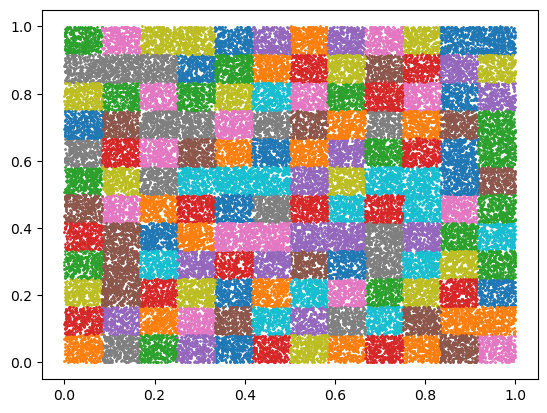

In [79]:
for key in samples_by_region.keys():
    plt.scatter(samples_by_region[key][:,0],samples_by_region[key][:,1],s=1)

xz projection:

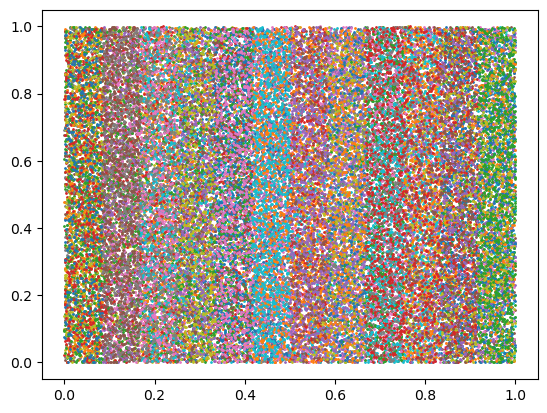

In [80]:
for key in samples_by_region.keys():
    plt.scatter(samples_by_region[key][:,0], samples_by_region[key][:,2],s=1)

#### Scenario 2

Set pseudo-random number generator for this experiment:

In [96]:
rng = np.random.default_rng(seed=1)

UNIFORM:

In [97]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
p=12

iid_counts_2 = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_5(sample_points,p,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts_2[dimensions-2,:,:] = unique_counts

In [98]:
uniform_mean_2 = np.mean(iid_counts_2,axis=1)
uniform_variances_2 = np.var(iid_counts_2,axis=1)

HALTON:

In [99]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
p = 12

halton_counts_2 = np.empty((max(all_dimensions)-1,runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,rng)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = scenario_2(sample_points,p,dimensions,runs,mode="online",return_samples=False)
    unique_counts = unique_counts.detach().numpy()
    halton_counts_2[dimensions-2,:,:] = unique_counts

SOBOL:

In [100]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
runs = 100
p = 12

sobol_counts_2 = np.empty((max(all_dimensions)-1,runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,rng)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = scenario_2(sample_points,p,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_2[dimensions-2,:,:] = unique_counts

BLUE NOISE:

In [101]:
p = 12
runs = 100
all_dimensions = [2,3,4,5,6,7,8,9,10]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_2 = np.empty((max(all_dimensions)-1,runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = scenario_2(sample_points,p,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_2[dimensions-2,:,:] = unique_counts

GRID:

In [110]:
p = 12
all_dimensions = [2,3,4,5,6,7,8,9,10]
# For each dimension, generate up to 50000 points in a regular grid 
points_per_axis = [np.arange(2,np.ceil(50000**(1/d))) for d in all_dimensions]
lower_bound = 1e-10
upper_bound = 1-1e-10

grid_counts_2 = []

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = points_per_axis[dimensions-2]
    grid_points = grid_sample(sample_points,dimensions,lower_bound,upper_bound)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = scenario_2(grid_points,p,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    grid_counts_2.append(unique_counts)

In [103]:
halton_mean_2 = np.mean(halton_counts_2,axis=1)
halton_variances_2 = np.var(halton_counts_2,axis=1)

In [104]:
sobol_mean_2 = np.mean(sobol_counts_2,axis=1)
sobol_variances_2 = np.var(sobol_counts_2,axis=1)

In [105]:
blue_noise_mean_2 = np.mean(blue_noise_counts_2,axis=1)
blue_noise_variances_2 = np.var(blue_noise_counts_2,axis=1)

In [106]:
sample_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

Bias graphs:

2D:

In [107]:
grid_sizes = [int(size) for size in points_per_axis[0]**2]

Text(0.5, 0, 'Number of Sampling Points')

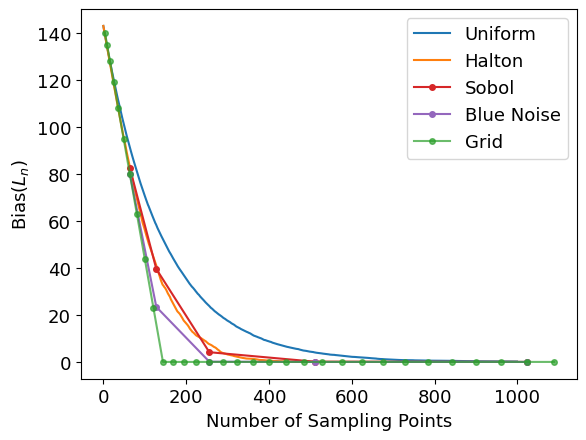

In [111]:
x = np.arange(1000)
plt.plot(x,144-uniform_mean_2[0,:1000],color="tab:blue",label="Uniform")
plt.plot(x,144-halton_mean_2[0,:1000],color="tab:orange",label="Halton")
plt.plot(sample_sizes[:5],144-sobol_mean_2[0][:5],color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:5],144-blue_noise_mean_2[0][:5],color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.plot(grid_sizes[:32],144-grid_counts_2[0][0][:32],marker="o",markersize=4,color="tab:green",alpha=0.7,label="Grid")
plt.legend()
plt.ylabel("Bias$(L_n)$")
plt.xlabel("Number of Sampling Points")

4D:

In [112]:
grid_sizes = [int(size) for size in points_per_axis[2]**4]

Text(0.5, 0, 'Number of Sampling Points')

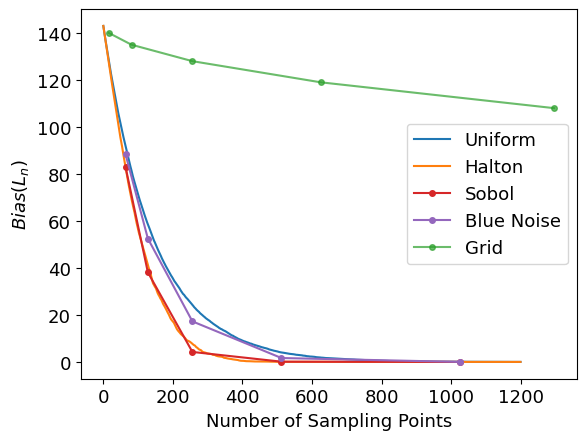

In [113]:
x = np.arange(1200)
plt.plot(x,144-uniform_mean_2[2,:1200],color="tab:blue",label="Uniform")
plt.plot(x,144-halton_mean_2[2,:1200],color="tab:orange",label="Halton")
plt.plot(sample_sizes[:5],144-sobol_mean_2[2,:5],color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:5],144-blue_noise_mean_2[2,:5],color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.plot(grid_sizes[:5],144-grid_counts_2[2][0][:5],marker="o",markersize=4,color="tab:green",alpha=0.7,label="Grid")
plt.legend()
plt.ylabel("$Bias(L_n)$")
plt.xlabel("Number of Sampling Points")

6D:

In [114]:
grid_sizes = [int(size) for size in points_per_axis[4]**6]

Text(0.5, 0, 'Number of Sampling Points')

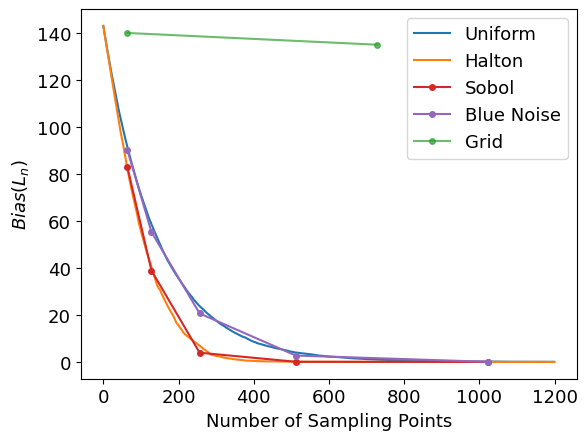

In [115]:
x = np.arange(1200)
plt.plot(x,144-uniform_mean_2[4,:1200],color="tab:blue",label="Uniform")
plt.plot(x,144-halton_mean_2[4,:1200],color="tab:orange",label="Halton")
plt.plot(sample_sizes[:5],144-sobol_mean_2[4,:5],color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:5],144-blue_noise_mean_2[4,:5],color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.plot(grid_sizes[:2],144-grid_counts_2[4][0][:2],marker="o",markersize=4,color="tab:green",alpha=0.7,label="Grid")
plt.legend()
plt.ylabel("$Bias(L_n)$")
plt.xlabel("Number of Sampling Points")

8D:

In [116]:
grid_sizes = [int(size) for size in points_per_axis[6]**8]

Text(0.5, 0, 'Number of Sampling Points')

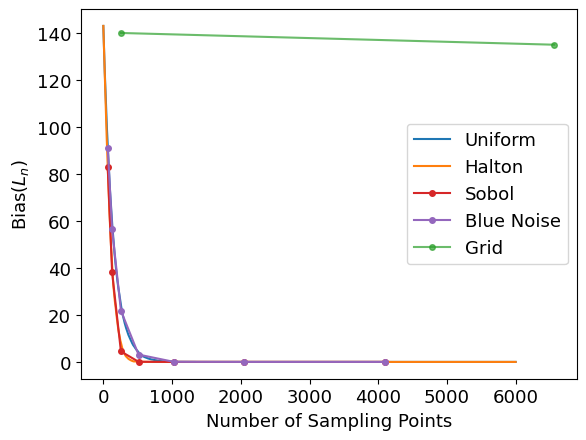

In [117]:
x = np.arange(6000)
plt.plot(x,144-uniform_mean_2[6,:6000],color="tab:blue",label="Uniform")
plt.plot(x,144-halton_mean_2[6,:6000],color="tab:orange",label="Halton")
plt.plot(sample_sizes[:7],144-sobol_mean_2[6,:7],color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:7],144-blue_noise_mean_2[6,:7],color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.plot(grid_sizes[:2],144-grid_counts_2[6][0][:2],marker="o",markersize=4,color="tab:green",alpha=0.7,label="Grid")
plt.legend()
plt.ylabel("Bias$(L_n)$")
plt.xlabel("Number of Sampling Points")

Standard deviation graphs:

2D:

Text(0.5, 0, 'Number of Sampling Points')

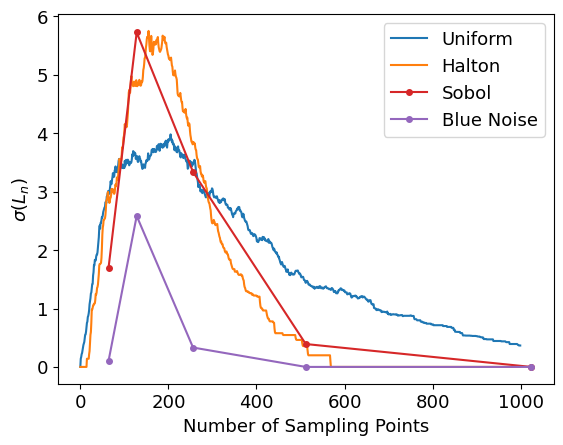

In [118]:
x = np.arange(1000)
plt.plot(x,np.sqrt(uniform_variances_2[0,:1000]),color="tab:blue",label="Uniform")
plt.plot(x,np.sqrt(halton_variances_2[0,:1000]),color="tab:orange",label="Halton")
plt.plot(sample_sizes[:5],np.sqrt(sobol_variances_2[0][:5]),color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:5],np.sqrt(blue_noise_variances_2[0][:5]),color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.legend()
plt.ylabel(r"$\sigma(L_n)$")
plt.xlabel("Number of Sampling Points")

4D:

Text(0.5, 0, 'Number of Sampling Points')

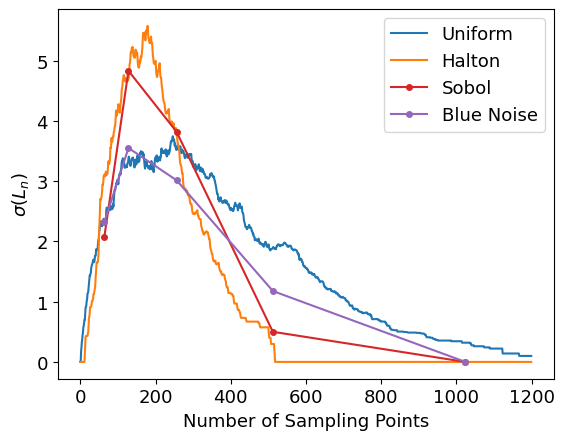

In [119]:
x = np.arange(1200)
plt.plot(x,np.sqrt(uniform_variances_2[2,:1200]),color="tab:blue",label="Uniform")
plt.plot(x,np.sqrt(halton_variances_2[2,:1200]),color="tab:orange",label="Halton")
plt.plot(sample_sizes[:5],np.sqrt(sobol_variances_2[2,:5]),color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:5],np.sqrt(blue_noise_variances_2[2,:5]),color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.legend()
plt.ylabel(r"$\sigma(L_n)$")
plt.xlabel("Number of Sampling Points")

6D:

Text(0.5, 0, 'Number of Sampling Points')

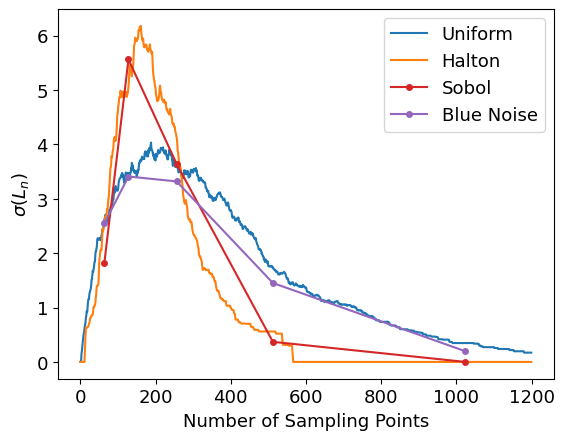

In [120]:
x = np.arange(1200)
plt.plot(x,np.sqrt(uniform_variances_2[4,:1200]),color="tab:blue",label="Uniform")
plt.plot(x,np.sqrt(halton_variances_2[4,:1200]),color="tab:orange",label="Halton")
plt.plot(sample_sizes[:5],np.sqrt(sobol_variances_2[4,:5]),color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:5],np.sqrt(blue_noise_variances_2[4,:5]),color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.legend()
plt.ylabel(r"$\sigma(L_n)$")
plt.xlabel("Number of Sampling Points")

8D:

Text(0.5, 0, 'Number of Sampling Points')

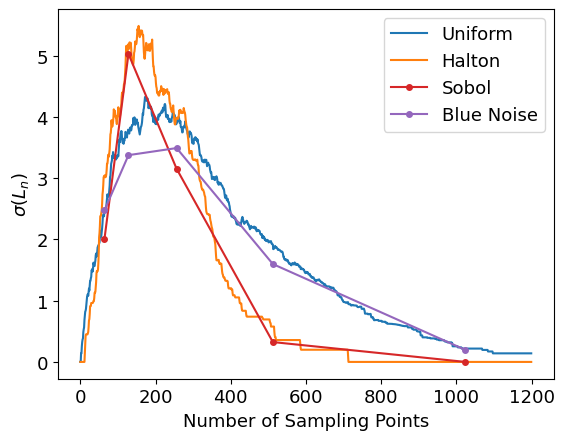

In [121]:
x = np.arange(1200)
plt.plot(x,np.sqrt(uniform_variances_2[6,:1200]),color="tab:blue",label="Uniform")
plt.plot(x,np.sqrt(halton_variances_2[6,:1200]),color="tab:orange",label="Halton")
plt.plot(sample_sizes[:5],np.sqrt(sobol_variances_2[6,:5]),color="tab:red",label="Sobol",marker="o",markersize=4)
plt.plot(sample_sizes[:5],np.sqrt(blue_noise_variances_2[6,:5]),color="tab:purple",label="Blue Noise",marker="o",markersize=4)
plt.legend()
plt.ylabel(r"$\sigma(L_n)$")
plt.xlabel("Number of Sampling Points")

#### Save Experiment Data:

In [122]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_2/iid_counts_scenario_2.npy',iid_counts_2)

In [123]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_2/halton_counts_scenario_2.npy',halton_counts_2)

In [124]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_2/sobol_counts_scenario_2.npy',sobol_counts_2)

In [125]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_2/blue_noise_counts_scenario_2.npy',blue_noise_counts_2)

In [126]:
np.savez('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_2/grid_counts_scenario_2.npz',*grid_counts_2)